# NLP Final Project: Amazon Customer Reviews

### Proje Açıklaması
Bu projede, Amazon’dan alınan elektronik ürün yorumları üzerinde doğal dil işleme (NLP) tekniklerini uygulayacağız. Kullanacağımız veriler, 63.001 benzersiz ürünle ilişkili 1.689.188 müşteri yorumunu içeriyor. Bu yorumlar üzerinden çeşitli NLP yöntemleri kullanarak olumlu ve olumsuz yorumların analizi ile bir sınıflandırma modeli geliştireceğiz.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import spacy
import joblib

In [36]:
# Gerekli NLTK paketlerini indirelim
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [37]:
# Veri Setini Yükleme
url = "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz"
print("Veri seti indiriliyor ve okunuyor...")

Veri seti indiriliyor ve okunuyor...


In [38]:
# Veriyi okuyup 400.000 örneklem alıyoruz
df = pd.read_json(url, lines=True, compression='gzip')
df = df.sample(400000, random_state=42).reset_index(drop=True)

In [39]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A3E3VF85DAW0FU,B004M8S12A,RedRover,"[57, 67]","Well, after trying out some Box Towers....that...",5,Best in Class,1307404800,"06 7, 2011"
1,A15X0XCY1EKJHL,B002KANXBG,"James Stitley ""Jim Stitley""","[16, 16]",I ordered one for my wife and one for me. Afte...,5,S 70 Review,1261612800,"12 24, 2009"
2,A393R1LK2A468F,B0050I1PHO,nelson 8A,"[3, 7]",muy buen producto... a full en juegos fHD.... ...,5,nice,1314576000,"08 29, 2011"
3,AEL8SXIP0GNYU,B000JNA4LS,Scott,"[0, 0]",The sound quality of this unit is phenomenal. ...,5,Crushes Bose SoundDock II,1235433600,"02 24, 2009"
4,A3O2Z9D0Y0G5XQ,B009VV56TY,Reese,"[0, 0]",It is good on keeping your cpu cool also down'...,4,it does what it say.,1401148800,"05 27, 2014"


In [40]:
df.shape

(400000, 9)

In [41]:
df

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A3E3VF85DAW0FU,B004M8S12A,RedRover,"[57, 67]","Well, after trying out some Box Towers....that...",5,Best in Class,1307404800,"06 7, 2011"
1,A15X0XCY1EKJHL,B002KANXBG,"James Stitley ""Jim Stitley""","[16, 16]",I ordered one for my wife and one for me. Afte...,5,S 70 Review,1261612800,"12 24, 2009"
2,A393R1LK2A468F,B0050I1PHO,nelson 8A,"[3, 7]",muy buen producto... a full en juegos fHD.... ...,5,nice,1314576000,"08 29, 2011"
3,AEL8SXIP0GNYU,B000JNA4LS,Scott,"[0, 0]",The sound quality of this unit is phenomenal. ...,5,Crushes Bose SoundDock II,1235433600,"02 24, 2009"
4,A3O2Z9D0Y0G5XQ,B009VV56TY,Reese,"[0, 0]",It is good on keeping your cpu cool also down'...,4,it does what it say.,1401148800,"05 27, 2014"
...,...,...,...,...,...,...,...,...,...
399995,A3TU4KJDB6351Q,B004E0ZLZQ,Popeye,"[4, 5]",I have owned similar products from LG and iLuv...,5,Amazing!,1298505600,"02 24, 2011"
399996,A2DOSF40F29ZOG,B007C9P3PO,MSBROWNSKATER,"[0, 0]",I bought this player to have when traveling an...,5,Great little player,1358726400,"01 21, 2013"
399997,A294BKN913UOGP,B000QUUFRW,"J. Moro ""JM""","[0, 0]",Updated: 8/7/2013:A few weeks ago I drove up ...,5,"A very fast, effective card",1344988800,"08 15, 2012"
399998,A1LHHZCRANBW4W,B0043TB7OC,"Robert Allocca ""Former Food Distributor""","[0, 0]",It's a Good Loud,5,Five Stars,1404777600,"07 8, 2014"


In [42]:
# Stopwords listesini set'e çevirmek arama hızını O(1)'e düşürür (Optimization)
stop_words = set(stopwords.words('english'))

In [43]:
# Metni temizler: HTML tagleri, noktalama işaretleri, sayılar kaldırılır.
# Stopwords temizlenir ve küçük harfe çevrilir.
def clean_text(text):
    if not isinstance(text, str): return ""
    # 1. HTML taglerini ve özel karakterleri kaldır (Regex kullanımı)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Sadece harfler ve boşluklar kalsın
    # 2. Küçük harfe çevir ve kelimelere ayır (Tokenization)
    text = text.lower().split()
    # 3. Stopwords temizliği (List Comprehension ile optimize kod)
    text = [word for word in text if word not in stop_words]
    return " ".join(text)

In [44]:
df['clean_text'] = df['reviewText'].apply(clean_text)

In [45]:
df

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,clean_text
0,A3E3VF85DAW0FU,B004M8S12A,RedRover,"[57, 67]","Well, after trying out some Box Towers....that...",5,Best in Class,1307404800,"06 7, 2011",well trying box towersthat sounded like music ...
1,A15X0XCY1EKJHL,B002KANXBG,"James Stitley ""Jim Stitley""","[16, 16]",I ordered one for my wife and one for me. Afte...,5,S 70 Review,1261612800,"12 24, 2009",ordered one wife one reading negative reviews ...
2,A393R1LK2A468F,B0050I1PHO,nelson 8A,"[3, 7]",muy buen producto... a full en juegos fHD.... ...,5,nice,1314576000,"08 29, 2011",muy buen producto full en juegos fhd hay probl...
3,AEL8SXIP0GNYU,B000JNA4LS,Scott,"[0, 0]",The sound quality of this unit is phenomenal. ...,5,Crushes Bose SoundDock II,1235433600,"02 24, 2009",sound quality unit phenomenal bose sounddock i...
4,A3O2Z9D0Y0G5XQ,B009VV56TY,Reese,"[0, 0]",It is good on keeping your cpu cool also down'...,4,it does what it say.,1401148800,"05 27, 2014",good keeping cpu cool also downt forget downlo...
...,...,...,...,...,...,...,...,...,...,...
399995,A3TU4KJDB6351Q,B004E0ZLZQ,Popeye,"[4, 5]",I have owned similar products from LG and iLuv...,5,Amazing!,1298505600,"02 24, 2011",owned similar products lg iluv cost far one ma...
399996,A2DOSF40F29ZOG,B007C9P3PO,MSBROWNSKATER,"[0, 0]",I bought this player to have when traveling an...,5,Great little player,1358726400,"01 21, 2013",bought player traveling love watched several m...
399997,A294BKN913UOGP,B000QUUFRW,"J. Moro ""JM""","[0, 0]",Updated: 8/7/2013:A few weeks ago I drove up ...,5,"A very fast, effective card",1344988800,"08 15, 2012",updated weeks ago drove summer home took lapto...
399998,A1LHHZCRANBW4W,B0043TB7OC,"Robert Allocca ""Former Food Distributor""","[0, 0]",It's a Good Loud,5,Five Stars,1404777600,"07 8, 2014",good loud


In [46]:
# Veri Görselleştirme: WordCloud (Kelime Bulutu)
def generate_wordcloud(data, title):
    text = " ".join(data.tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

In [47]:
# Pozitif (5 Yıldız) ve Negatif (1 Yıldız) yorumları ayır
positive_reviews = df[df['overall'] == 5]['clean_text']
negative_reviews = df[df['overall'] == 1]['clean_text']

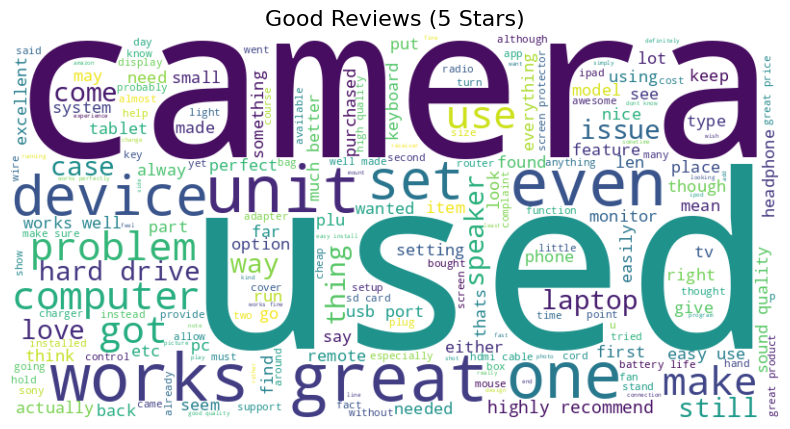

In [15]:
# Pozitif Yorumlar Kelime Bulutu
generate_wordcloud(positive_reviews, "Good Reviews (5 Stars)")

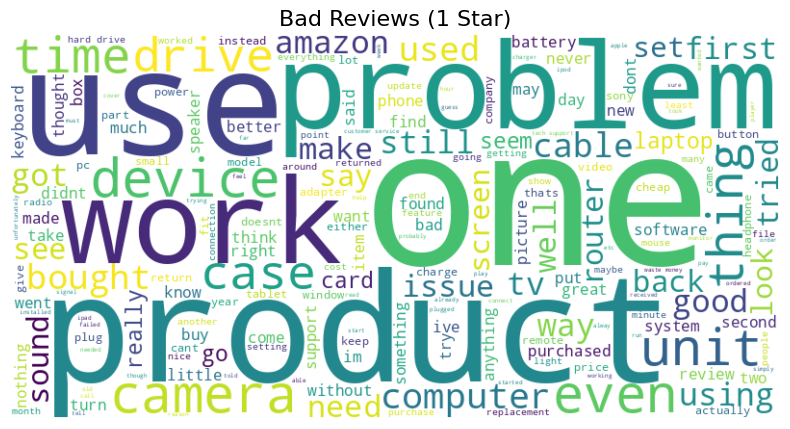

In [16]:
# Negatif Yorumlar Kelime Bulutu
generate_wordcloud(negative_reviews, "Bad Reviews (1 Star)")

In [17]:
# Modelleme: Sınıflandırma (Classification)

In [48]:
# Hedef Değişkeni (Rating) 3 Sınıfa İndirgeme (Sentiment Grouping)
def categorize_sentiment(rating):
    if rating <= 2:
        return 0 # Negatif
    elif rating == 3:
        return 1 # Nötr
    else:
        return 2 # Pozitif

In [49]:
# Yeni hedef değişkeni oluştur
df['sentiment'] = df['overall'].apply(categorize_sentiment)

In [50]:
# Veri Hazırlığı
X = df['clean_text']
y = df['sentiment']

In [51]:
X

,clean_text
0,well trying box towersthat sounded like music ...
1,ordered one wife one reading negative reviews ...
2,muy buen producto full en juegos fhd hay probl...
3,sound quality unit phenomenal bose sounddock i...
4,good keeping cpu cool also downt forget downlo...
...,...
399995,owned similar products lg iluv cost far one ma...
399996,bought player traveling love watched several m...
399997,updated weeks ago drove summer home took lapto...
399998,good loud


In [52]:
y

,sentiment
0,2
1,2
2,2
3,2
4,2
...,...
399995,2
399996,2
399997,2
399998,2


In [53]:
# Eğitim ve Test seti ayırma (%80 Eğitim, %20 Test)
# Not: 'stratify=y' her sınıftan eşit oranda dağıtılmasını sağlar, çok önemlidir!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [54]:
# Vektörleştirme (TF-IDF) - En sık geçen 5000 kelimeyi kullanacağız
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
# ngram_range=(1,2) ekledik: "not good" gibi ikilileri de yakalasın diye.
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [55]:
# class_weight='balanced': Az olan sınıflara (Negatif/Nötr) daha çok ağırlık ver.
model = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
model.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [56]:
# Tahmin ve Değerlendirme
y_pred = model.predict(X_test_vec)

In [57]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.54      0.71      0.61      9066\n           1       0.22      0.54      0.32      6679\n           2       0.96      0.78      0.86     64255\n\n    accuracy                           0.75     80000\n   macro avg       0.58      0.68      0.60     80000\nweighted avg       0.85      0.75      0.79     80000\n'

In [58]:
nlp = spacy.load("en_core_web_sm")

In [61]:
# Duygu etiketlerinin eşleştirilmesi (Sınıf 0, 1, 2'nin ne anlama geldiği)
sentiment_labels = {
    0: "Negatif (1-2 Yıldız)",
    1: "Nötr (3 Yıldız)",
    2: "Pozitif (4-5 Yıldız)"
}

In [62]:
# Yeni bir yorumu tahmin ederken, sayısal etiket yerine metinsel duygu etiketini kullanır.
def predict_review_and_extract_entities_v2(new_review, model, vectorizer):
    # 1. Tahmin
    cleaned = clean_text(new_review) # clean_text fonksiyonunu önceki adımlardan aldık
    vectorized = vectorizer.transform([cleaned])
    prediction_label = model.predict(vectorized)[0] # Sayısal etiket (0, 1 veya 2)

    # Sayısal etiketi, kullanıcı dostu duygu metnine çevir
    prediction_sentiment = sentiment_labels[prediction_label]

    # 2. NER (Varlık Tanıma)
    doc = nlp(new_review)
    entities = [(ent.text, ent.label_) for ent in doc.ents]

    print(f"Yorum: {new_review}")
    print(f"Tahmin Edilen Duygu: **{prediction_sentiment}**")
    print(f"Tespit Edilen Varlıklar (NER): {entities}\n")
    print("-" * 50)

In [63]:
# Testler
sample_review_1 = "I bought a new iPhone from Apple store in New York, but the battery life is terrible."
sample_review_2 = "Sony headphones are amazing! The sound quality beats Bose and the price is great."
predict_review_and_extract_entities_v2(sample_review_1, model, vectorizer)
predict_review_and_extract_entities_v2(sample_review_2, model, vectorizer)

Yorum: I bought a new iPhone from Apple store in New York, but the battery life is terrible.
Tahmin Edilen Duygu: **Negatif (1-2 Yıldız)**
Tespit Edilen Varlıklar (NER): [('Apple', 'ORG'), ('New York', 'GPE')]

--------------------------------------------------
Yorum: Sony headphones are amazing! The sound quality beats Bose and the price is great.
Tahmin Edilen Duygu: **Pozitif (4-5 Yıldız)**
Tespit Edilen Varlıklar (NER): [('Sony', 'ORG'), ('Bose', 'PERSON')]

--------------------------------------------------


In [65]:
# Gayet basarili sonuclar elde ettik. Simde modelleri kaydedelim.
joblib.dump(model, 'amazon_nlp_sentiment_model.joblib')
joblib.dump(vectorizer, 'amazon_tfidf_vectorizer.joblib')

['amazon_tfidf_vectorizer.joblib']